In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../../Data/concrete_data.csv")
df

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30
...,...,...,...,...,...,...,...,...,...
1025,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28,44.28
1026,322.2,0.0,115.6,196.0,10.4,817.9,813.4,28,31.18
1027,148.5,139.4,108.6,192.7,6.1,892.4,780.0,28,23.70
1028,159.1,186.7,0.0,175.6,11.3,989.6,788.9,28,32.77


In [3]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.iloc[:,:-1],df.iloc[:,-1], test_size=0.2, random_state=42)

# 1. Without Power Transformer

In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import cross_val_score
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
print("R2:",  r2_score(y_test, y_pred))


R2: 0.6275531792314848


In [5]:
from sklearn.tree import DecisionTreeRegressor
dtr = DecisionTreeRegressor()
dtr.fit(X_train, y_train)
y_pred = dtr.predict(X_test)
print("R2:",  r2_score(y_test, y_pred))

R2: 0.8375785154621262


In [6]:
lr = LinearRegression()
X = df.iloc[:,:-1]
y = df.iloc[:,-1]
print("Cross Val Score:",np.mean(cross_val_score(lr, X,y, cv=10)))

Cross Val Score: 0.27820729160873753


# Reason (not normal)

C:\Users\Jehan\AppData\Local\Temp\ipykernel_14220\4129189162.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[col])
C:\Users\Jehan\AppData\Local\Temp\ipykernel_14220\4129189162.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[col])
C:\Users\Jehan\AppData\Local\Temp\ipykerne

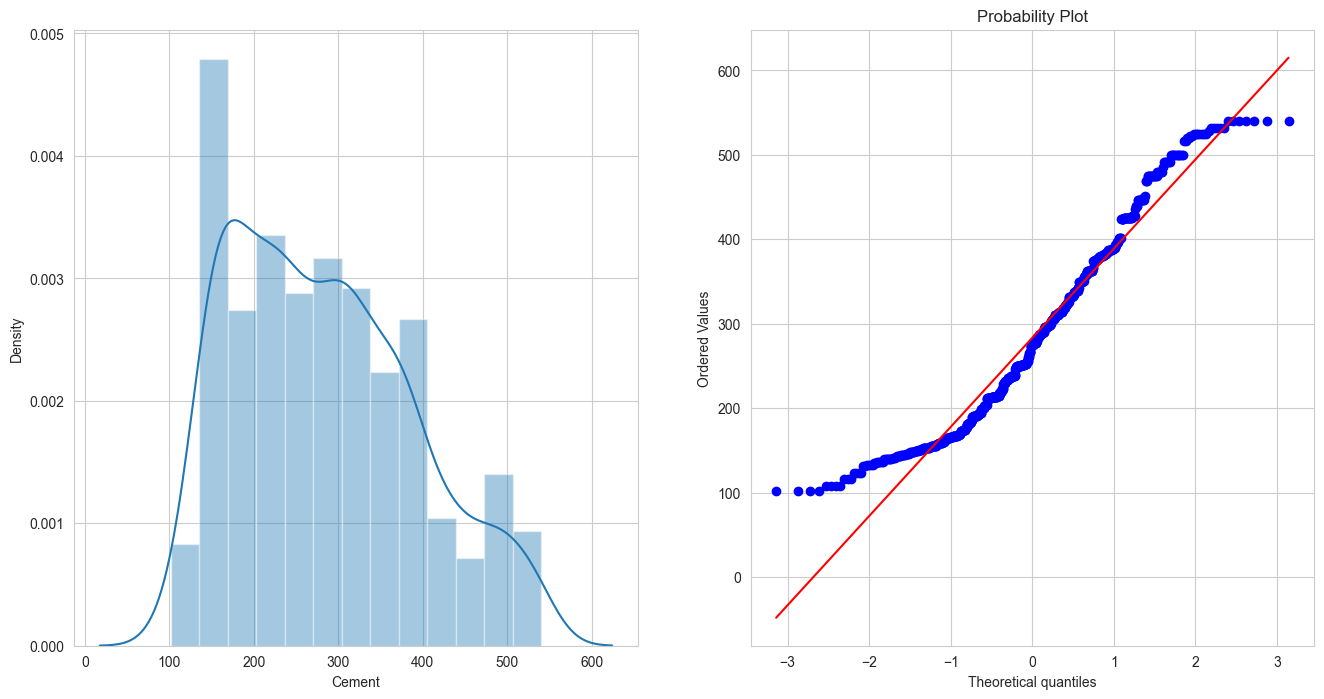

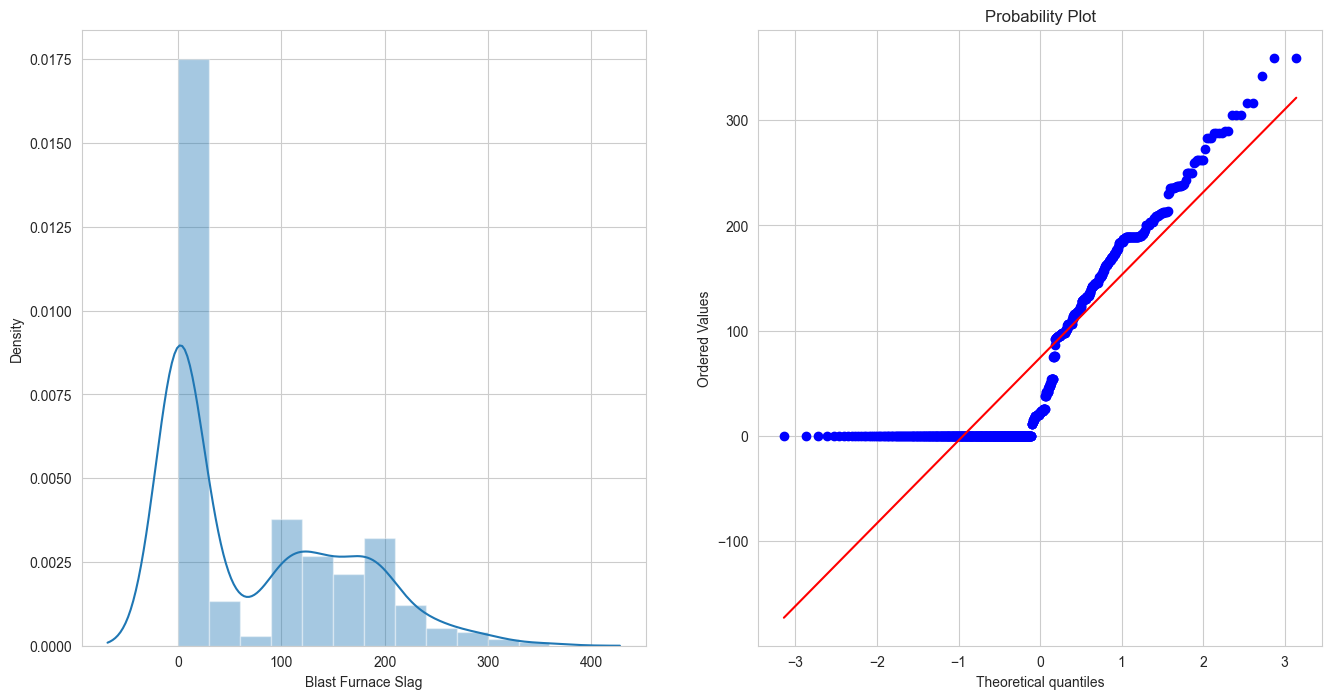

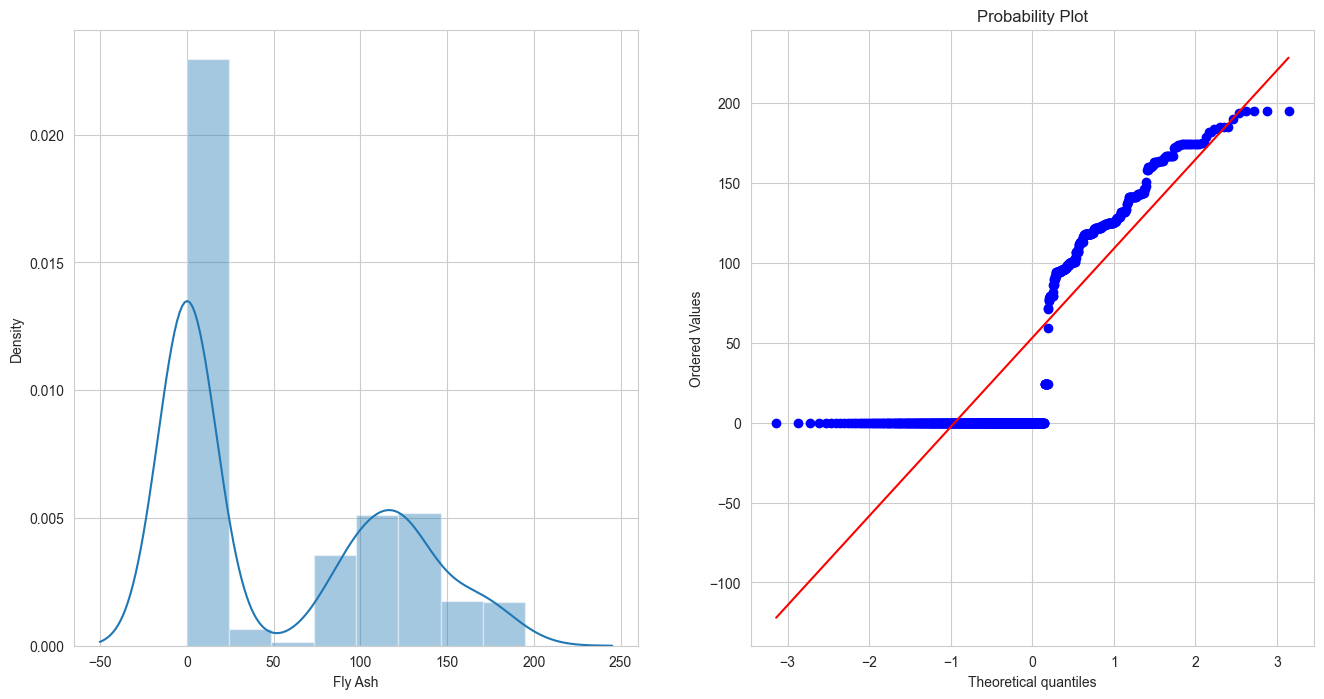

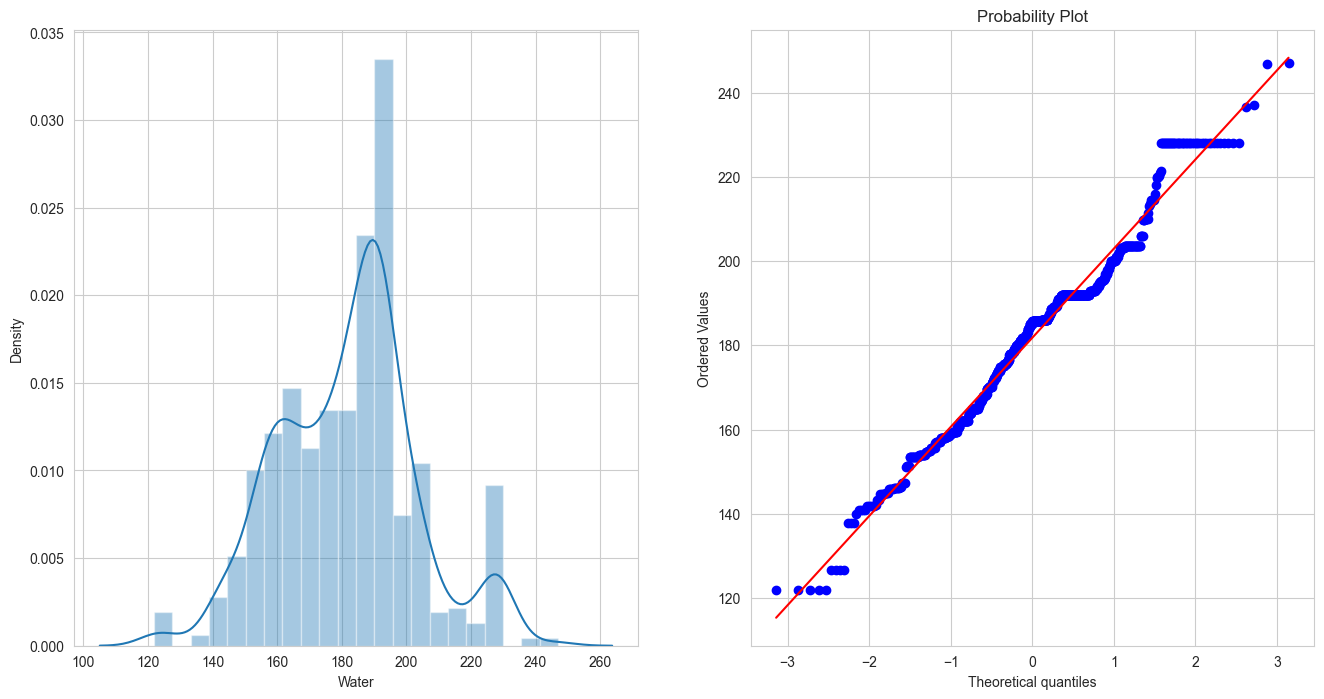

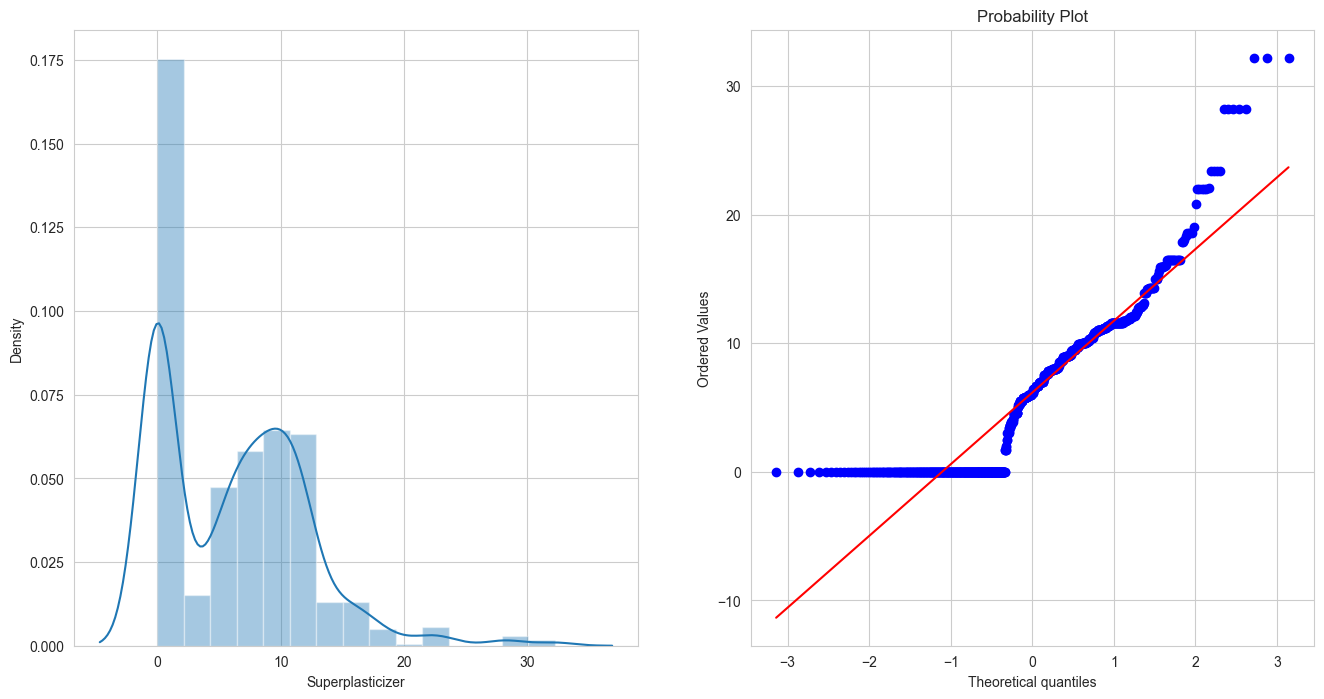

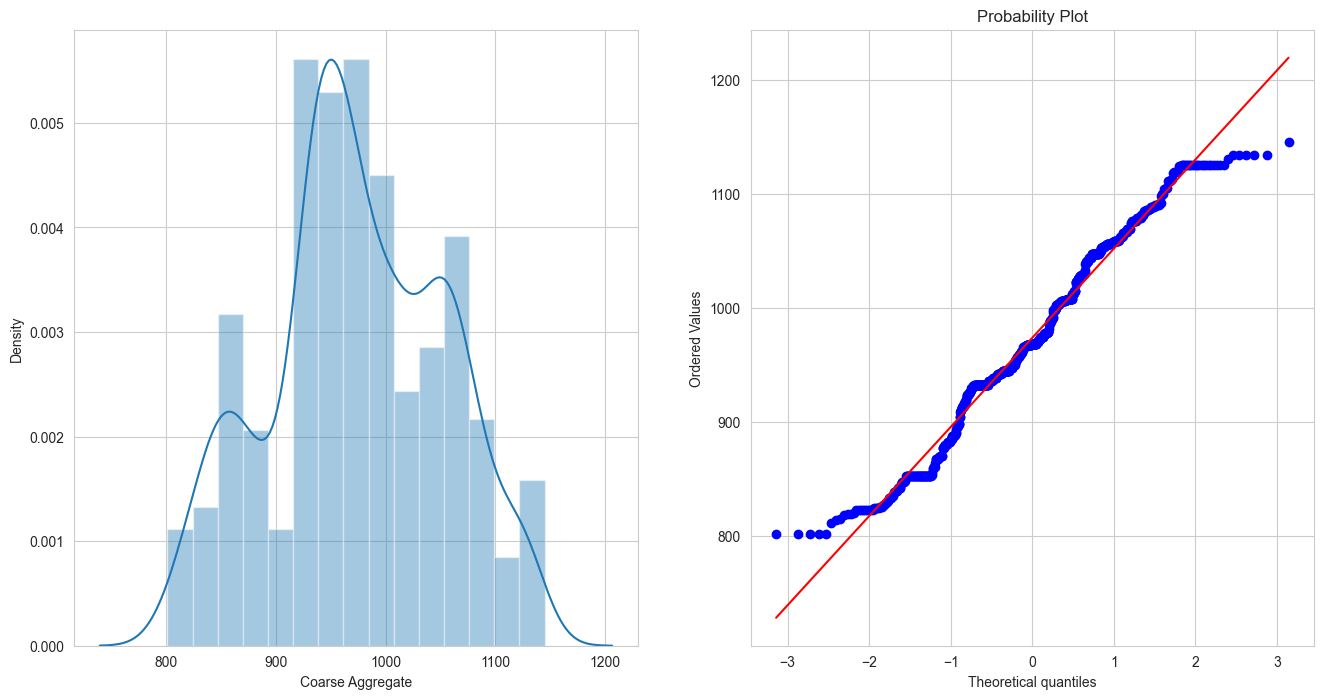

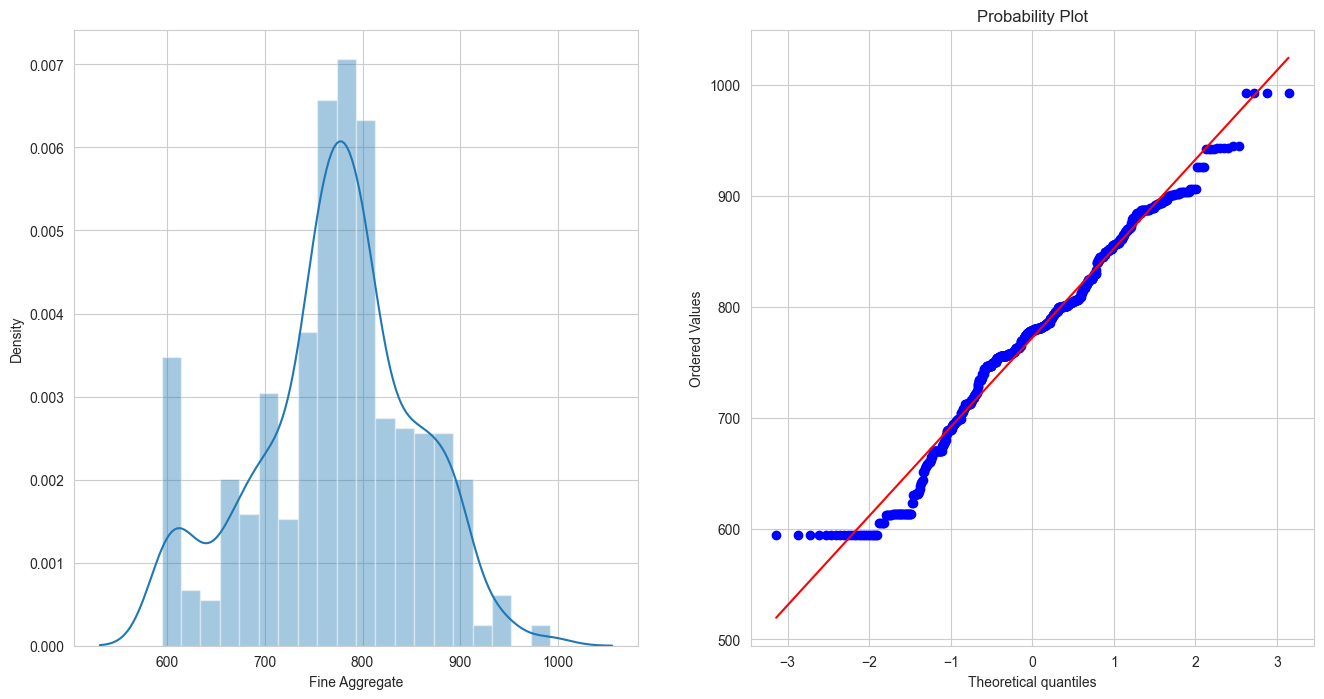

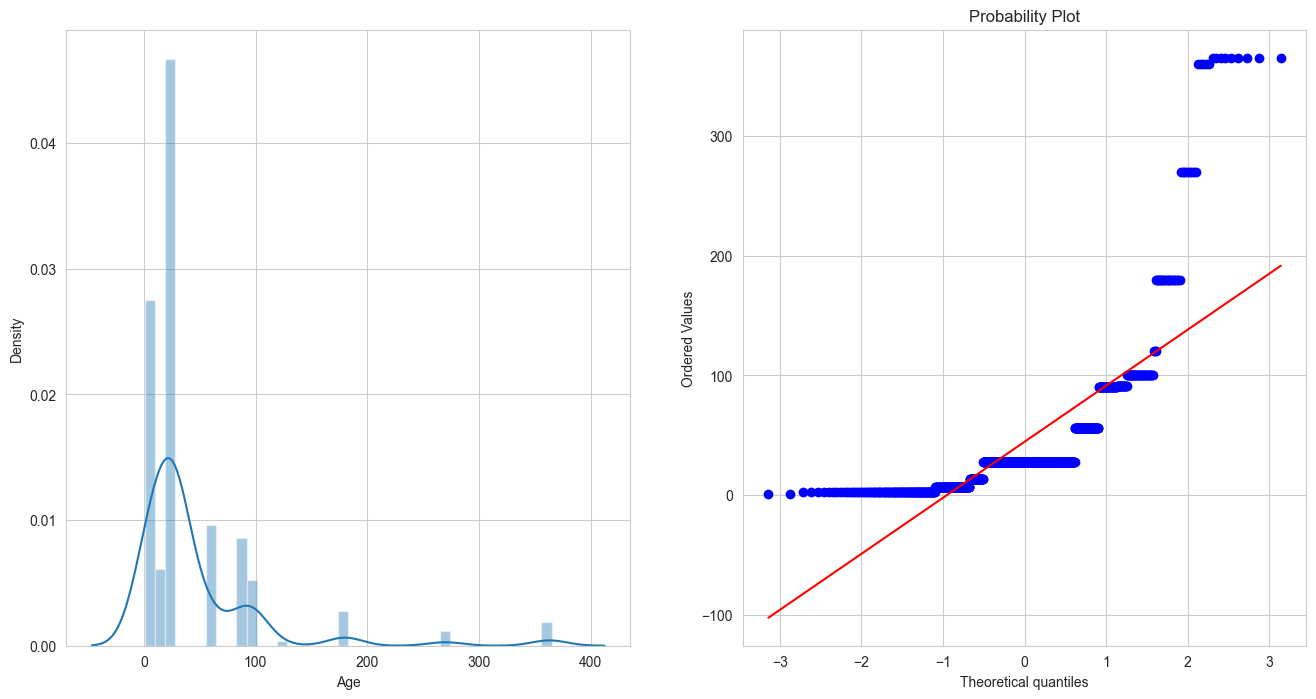

In [7]:
import scipy.stats as stats
for col in X_train.columns:
    plt.figure(figsize=(16,8))
    
    plt.subplot(121)
    sns.distplot(X_train[col])
    
    plt.subplot(122)
    stats.probplot(X_train[col], dist='norm', plot=plt)

# 2. Using Yeo Jhonson Power Transformer

In [8]:
from sklearn.preprocessing import PowerTransformer
ptrf_yeo = PowerTransformer()
X_train_trf_yeo = ptrf_yeo.fit_transform(X_train)
X_test_trf_yeo = ptrf_yeo.transform(X_test)

In [9]:
lr = LinearRegression()
lr.fit(X_train_trf_yeo, y_train)
y_pred = lr.predict(X_test_trf_yeo)
print("R2:", r2_score(y_test, y_pred))

R2: 0.8161906511066099


In [10]:
dtr = DecisionTreeRegressor()
dtr.fit(X_train_trf_yeo, y_train)
y_pred = dtr.predict(X_test_trf_yeo)
print("R2:", r2_score(y_test, y_pred))

R2: 0.8323543015230871


In [11]:
lr = LinearRegression()
X = df.iloc[:, :-1]
X_trf_yeo = ptrf_yeo.fit_transform(X)
y = df.iloc[:, -1]
print("Cross Val Score:", np.mean(cross_val_score(lr, X_trf_yeo, y, cv=10)))

Cross Val Score: 0.6586548619389643


# 3.  Using Yeo Box-Cox Power Transformer

In [12]:
from sklearn.preprocessing import PowerTransformer

ptrf_boxCox = PowerTransformer(method='box-cox')
X_train_trf_boxCox = ptrf_boxCox.fit_transform(X_train + 0.00000001)
X_test_trf_boxCox = ptrf_boxCox.transform(X_test + 0.00000001)

In [13]:
lr = LinearRegression()
lr.fit(X_train_trf_boxCox, y_train)
y_pred = lr.predict(X_test_trf_boxCox)
print("R2:", r2_score(y_test, y_pred))

R2: 0.8038298017767421


In [14]:
dtr = DecisionTreeRegressor()
dtr.fit(X_train_trf_boxCox, y_train)
y_pred = dtr.predict(X_test_trf_boxCox)
print("R2:", r2_score(y_test, y_pred))

R2: 0.8307078503415296


In [16]:
lr = LinearRegression()
X = df.iloc[:, :-1]
X_trf_boxCox = ptrf_boxCox.fit_transform(X + 0.00000001)
y = df.iloc[:, -1]
print("Cross Val Score:", np.mean(cross_val_score(lr, X_trf_boxCox, y, cv=10)))

Cross Val Score: 0.6456670375054756


C:\Users\Jehan\AppData\Local\Temp\ipykernel_14220\2261474045.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[col])
C:\Users\Jehan\AppData\Local\Temp\ipykernel_14220\2261474045.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train_trf_yeo[index])
C:\Users\Jehan\AppData\Local\Tem

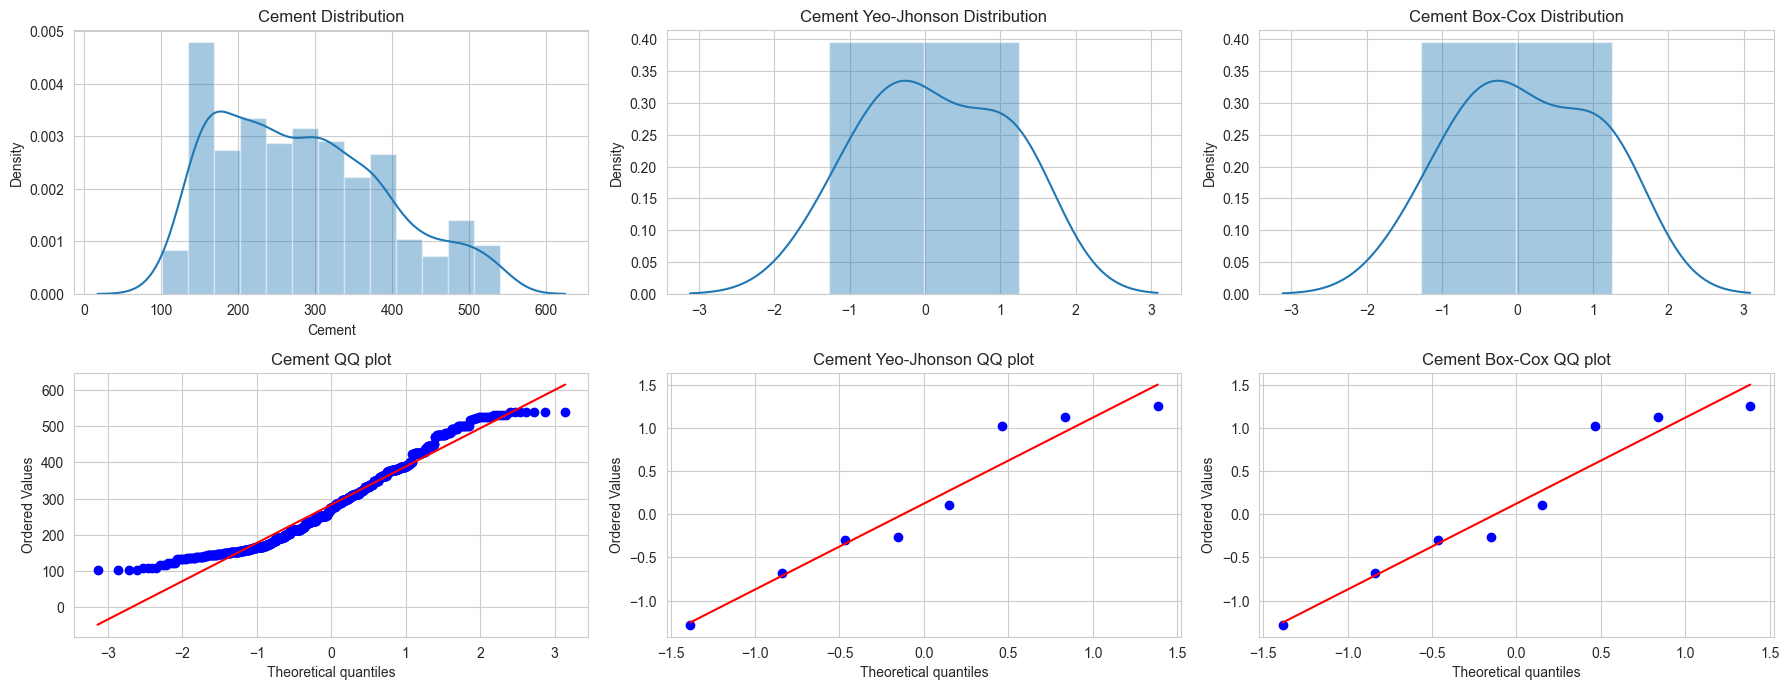

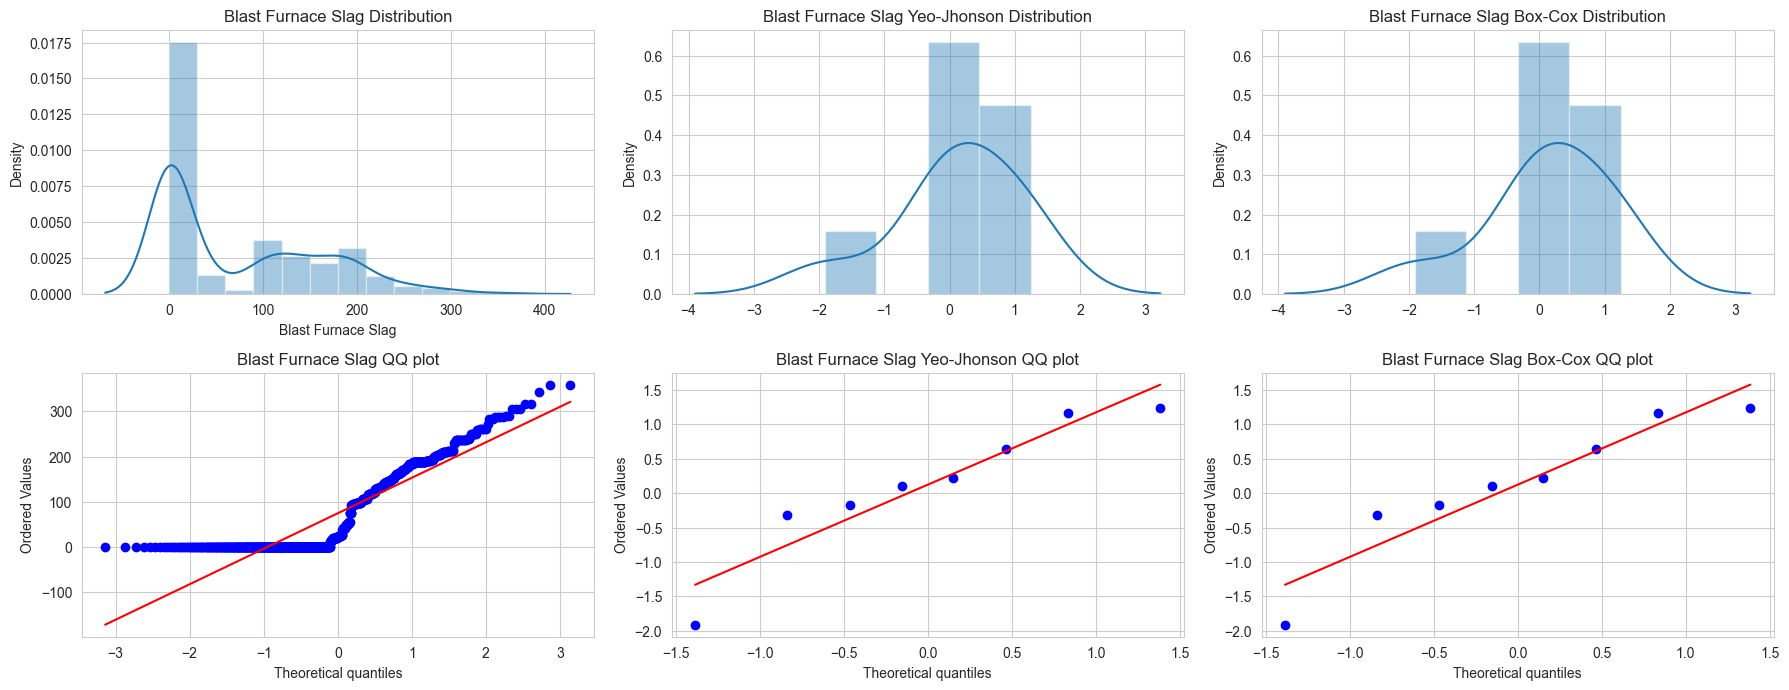

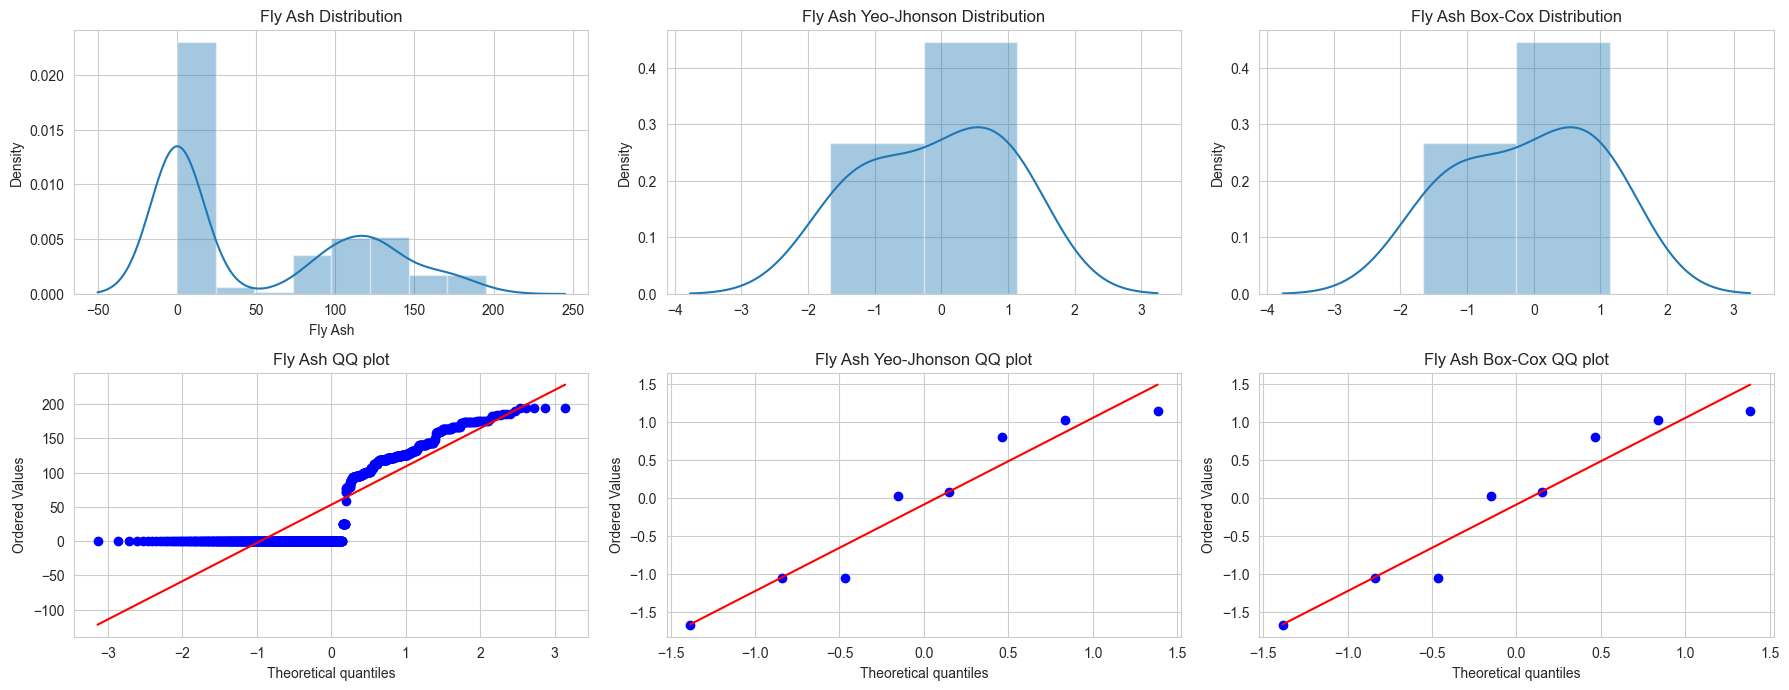

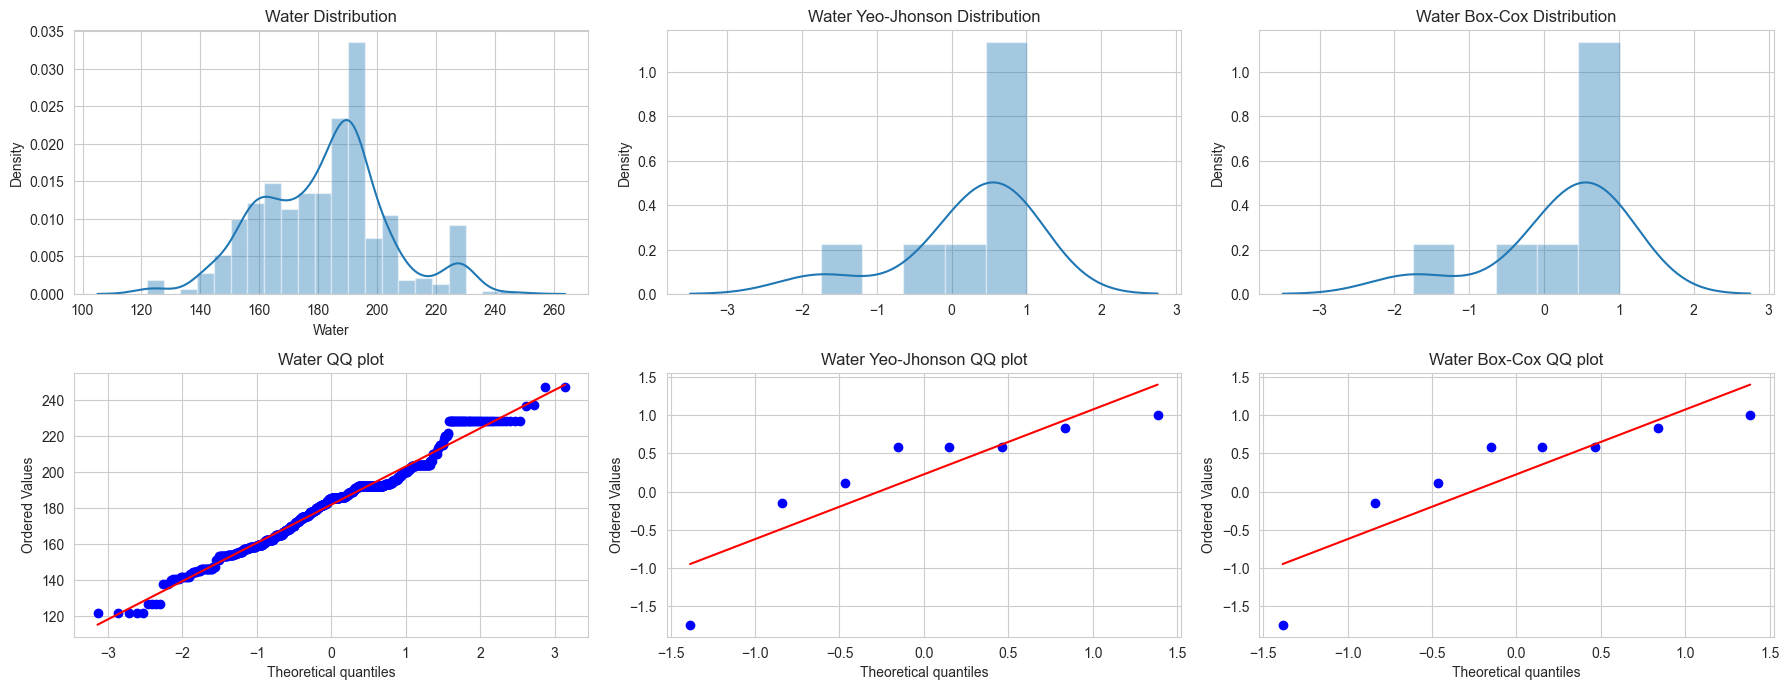

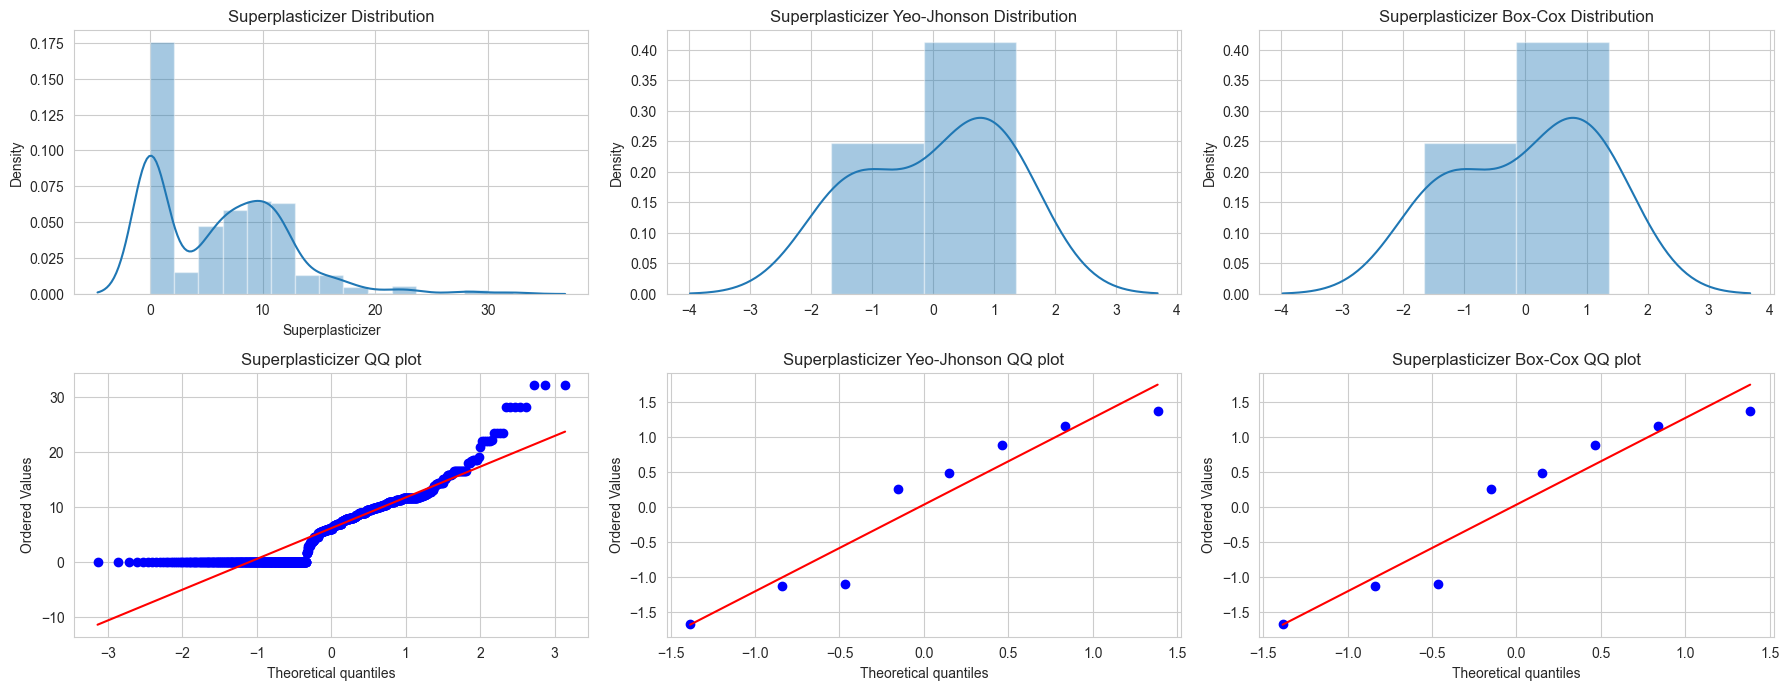

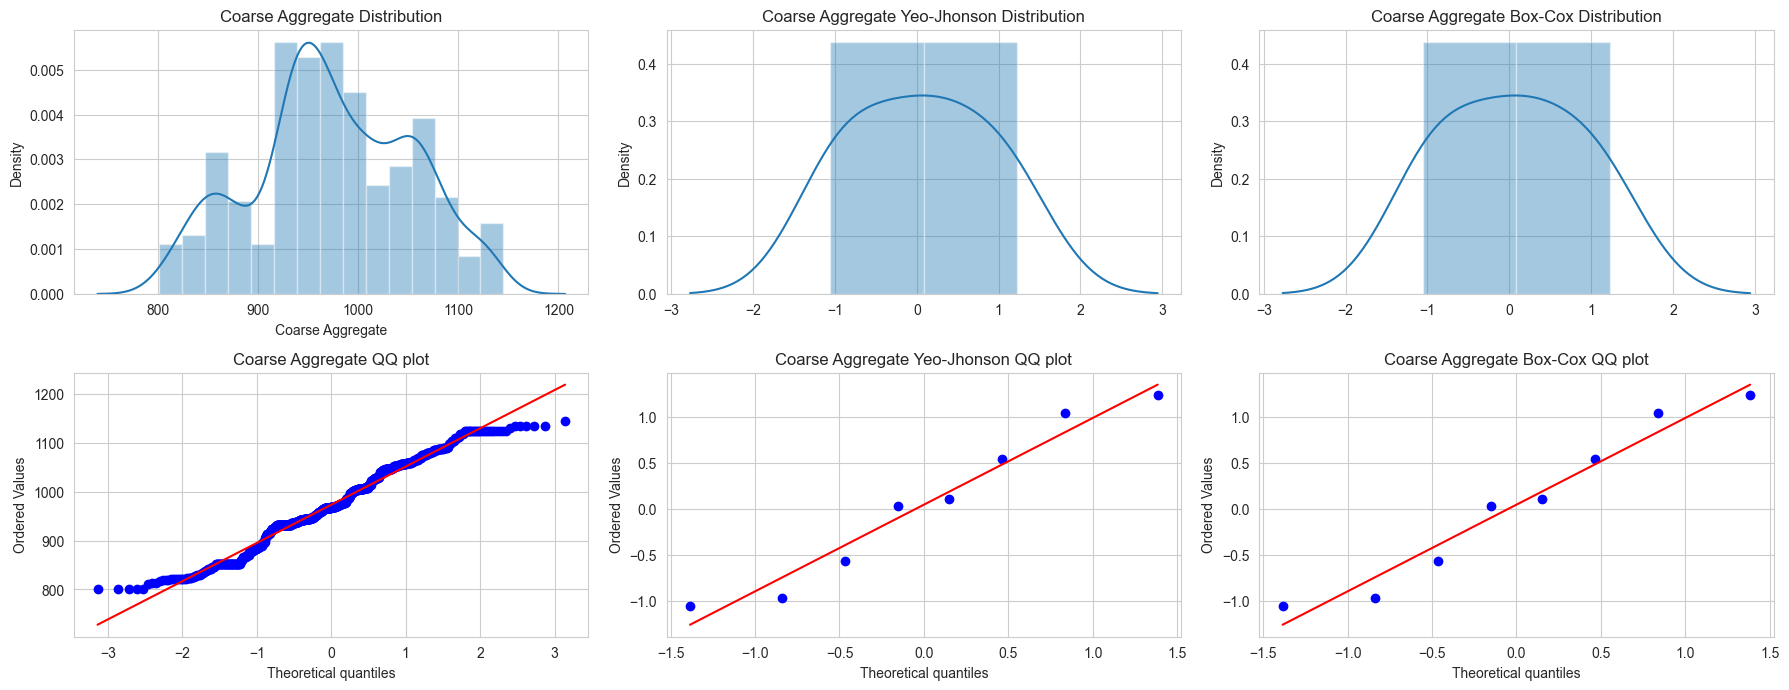

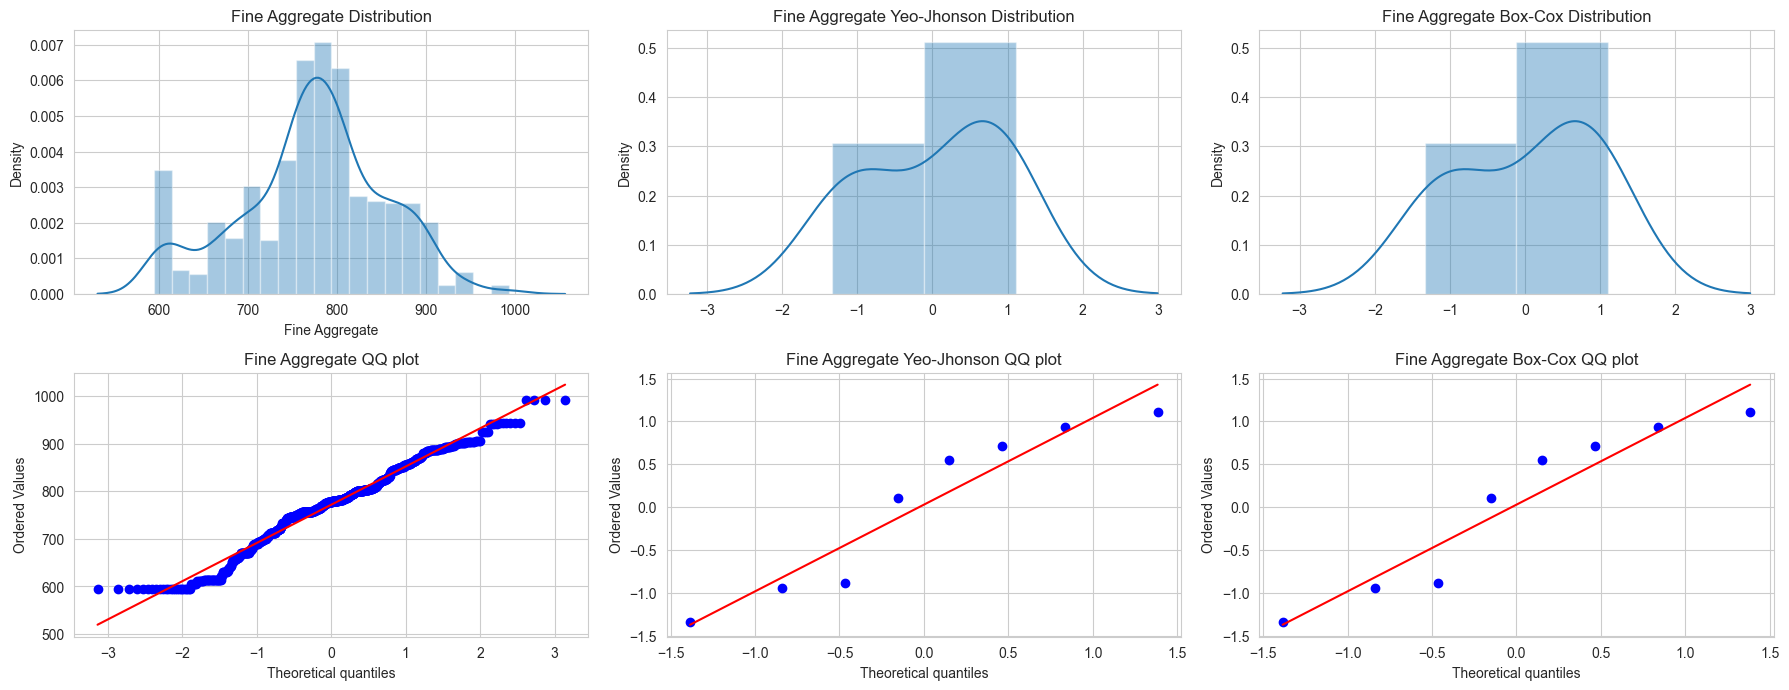

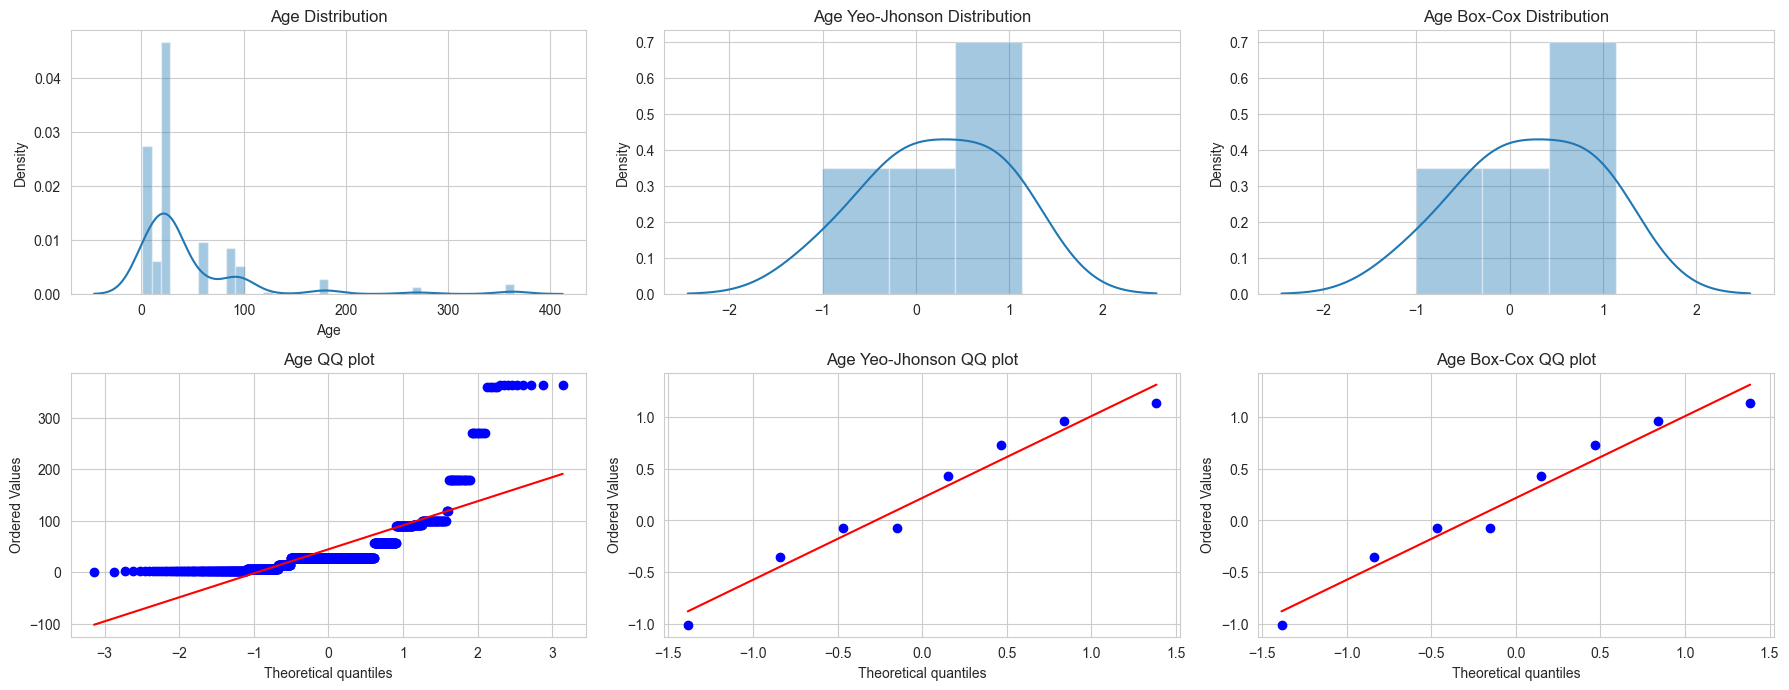

In [21]:
for index, col in enumerate(X_train.columns):
    plt.figure(figsize=(18,10))
    plt.subplot(331)
    sns.distplot(X_train[col])
    plt.title(f'{col} Distribution')
    plt.subplot(332)
    sns.distplot(X_train_trf_yeo[index])
    plt.title(f'{col} Yeo-Jhonson Distribution')
    plt.subplot(333)
    sns.distplot(X_train_trf_yeo[index])
    plt.title(f'{col} Box-Cox Distribution')
    plt.subplot(334)
    stats.probplot(X_train[col], dist='norm', plot=plt)
    plt.title(f'{col} QQ plot')
    plt.subplot(335)
    stats.probplot(X_train_trf_yeo[index], dist='norm', plot=plt)
    plt.title(f'{col} Yeo-Jhonson QQ plot')
    plt.subplot(336)
    stats.probplot(X_train_trf_yeo[index], dist='norm', plot=plt)
    plt.title(f'{col} Box-Cox QQ plot')
    plt.tight_layout()